Error at 0.0 is 0.0
Error at 0.1 is 0.018731
Error at 0.2 is 0.03032
Error at 0.3 is 0.036812
Error at 0.4 is 0.039729
Error at 0.5 is 0.040199
Error at 0.6 is 0.03905
Error at 0.7 is 0.036882
Error at 0.8 is 0.034124
Error at 0.9 is 0.031081
Error at 1.0 is 0.027961
Error at 1.1 is 0.024904
Error at 1.2 is 0.021998
Error at 1.3 is 0.019298
Error at 1.4 is 0.01683
Error at 1.5 is 0.014603
Error at 1.6 is 0.012615
Error at 1.7 is 0.010855
Error at 1.8 is 0.009309
Error at 1.9 is 0.007959
Error at 2.0 is 0.006786
Total accumulated error for h = 0.1: 0.480047



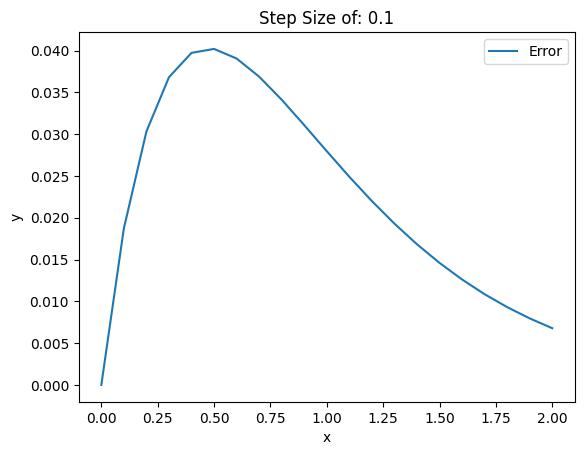

Error at 0.0 is 0.0
Error at 0.5 is 0.367879
Error at 1.0 is 0.135335
Error at 1.5 is 0.049787
Error at 2.0 is 0.018316
Total accumulated error for h = 0.5: 0.571317



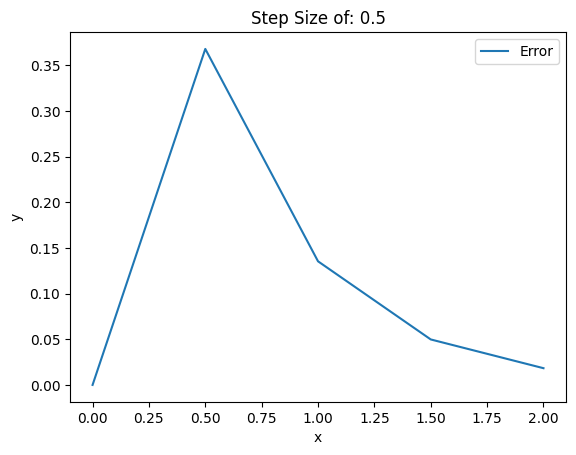

Error at 0.0 is 0.0
Error at 1.0 is 1.135335
Error at 2.0 is 0.981684
Total accumulated error for h = 1.0: 2.11702



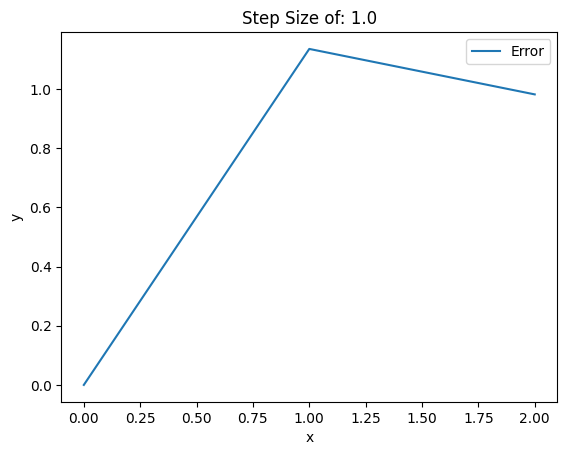

Error at 0.0 is 0.0
Error at 1.5 is 2.049787
Error at 3.0 is 4.014633
Total accumulated error for h = 1.5: 6.06442



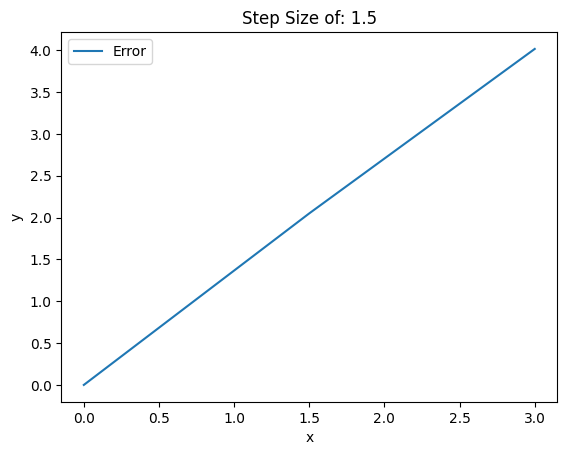

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

steps = [0.1, 0.5, 1.0, 1.5]
def exp(x):
    return np.exp(x)




def eulerMethodPerStep(steps):
    isFirstRun = 1
    firstFunc_x = 0
    firstFunc_y = 0
    
    for j in range(len(steps)):
        # Define parameters
        h = steps[j]  # step size
        
        x_values = np.arange(0, 2 + h, h)  # +h so we include endpoint
        y_values = np.zeros(x_values.size)
        
        # Initial condition
        y_values[0] = 1  # y(0) = 1
        
        # Function representing dy/dx = -2y
        def f(x, y):
            return -2 * y
        
        # Implement Euler's method
        
        for i in range(x_values.size - 1):
        
            y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
        if(isFirstRun):
            firstFunc_x = x_values
            firstFunc_y = exp(-2 * x_values)
            isFirstRun = 0
        


        cs = CubicSpline(firstFunc_x, firstFunc_y)
        firstFunc_interp = cs(x_values)

        totalError = 0
        pointError = []
        for k in range(y_values.size):
            pointError.append(abs(firstFunc_interp[k] - y_values[k]))
            totalError += pointError[k]
            print("Error at " + str(round(x_values[k], 4)) + " is " + str(round(pointError[k], 6)))
        
        print("Total accumulated error for h = " + str(round(steps[j], 2)) + ": " + str(round(totalError, 6)) + "\n")


        # Plot the results
        
        plt.plot(x_values, pointError, label="Error")

        plt.xlabel('x')
        
        plt.ylabel('y')
        
        plt.title("Step Size of: " +  str(round(steps[j], 2)))
        
        plt.legend()
        
        plt.show()

eulerMethodPerStep(steps)